<h1> Epsilon Greedy Baseline

In [91]:
import numpy as np
import matplotlib.pyplot as plt

from src.bandit import (
    MultiArmedBandit,
    EpsilonGreedyAgent
)

<h3> Step 1: Creating a Multi-Armed Bandit Environment

First, we construct the environment.
In the Bandit setting, we have several actions.
Each action has a reward distribution.

In [92]:
bandit = MultiArmedBandit(
    n_arms=10
)

bandit.means

array([ 0.70311309, -0.90254098,  0.36188327,  1.36627284, -0.00512888,
       -1.50208188, -1.19694441,  0.56660286,  1.10569795, -1.43568867])

The agent has selected arm number 3 and requested a reward from the environment.

The environment generates a sample from the following distribution:

$Reward \sim N(mean_{arm3}, 1)$


**Important note:**

This figure does not represent the true value of the Arm.

Rather, it simply reflects the reward returned by the environment for selecting Arm 3 in this instance.

In [93]:
bandit.step(3)

2.463647113024587

<h3> Step 2: Base Bandit Agent 

##### Update Rule

Formula:

$Q_{new}=Q_{old}+
\frac{1}{N}
(R-Q_{old})
$

Meaning:</br>
Shift the previous estimate slightly towards the new reward.

<h3> Step 3: ε-Greedy Agent

Idea:

Sometimes choose the best option currently known to us:
Exploitation

Sometimes try something at random:
Exploration

Rule:

With probability: $\epsilon$ Random selection.

With probability: $1-\epsilon$ The current best action.

In [94]:
agent = EpsilonGreedyAgent(
    10,
    epsilon=0.1
)

In [95]:
# for i in range (100):
action = agent.select_action()

reward = bandit.step(
    action
)

agent.update(
    action,
    reward
)
    # print(f"\n{i} : ", agent.values)

In [96]:
agent.values

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , -1.74220749])

<h3> Step 3.1: Executing the Training Loop

Let’s train the agent for a large number of steps and see whether it actually finds the best arm.

In [97]:
def run_agent(
    bandit,
    agent,
    steps=1000
):
    rewards = []
    actions = []

    for _ in range(steps):
        action = agent.select_action()
        reward = bandit.step(action)
        agent.update(
            action,
            reward
        )

        rewards.append(reward)
        actions.append(action)

    return rewards, actions

Each iteration:
1. Agent makes a decision:
select_action()

2. Environment responds:
step(action)

3. Agent learns:
update()

Running the first experiment:

In [98]:
bandit = MultiArmedBandit(
    n_arms=10
)

To make a comparison, we need to know which ARM is the best.

In [99]:
best_arm = np.argmax(
    bandit.means
)

best_reward = bandit.means[
    best_arm
]

print(best_arm)
print(best_reward)

8
1.405040025568334


Creating an Agent:

In [100]:
agent = EpsilonGreedyAgent(
    n_arms=10,
    epsilon=0.1
)

In [101]:
rewards, actions = run_agent(
    bandit,
    agent,
    5000
)

In [102]:
agent.values

array([ 1.24427244,  0.28190855,  0.99841103, -0.26368986, -1.5070738 ,
       -0.15456299,  0.23780325, -1.57471647,  1.41750411, -0.24364235])

In [103]:
rewards

[1.2836765015173224,
 1.2778399959664957,
 -0.10280170039069113,
 -0.18500355111498956,
 -0.7175123363276532,
 0.29556380689876904,
 0.7847129753997268,
 0.35475799273642283,
 0.12030490460658685,
 0.15900420755851064,
 -0.5148992805608175,
 -1.378916995858929,
 -0.08305421613883152,
 0.8650374397836988,
 -1.9975816530983577,
 0.3696080891974537,
 -0.3966078492498136,
 -3.1052401419128226,
 -1.1785098897825304,
 -0.7210843677089462,
 0.35606411712296454,
 0.057591146249394265,
 -0.45662774084882435,
 0.36942188516235286,
 2.880464132982043,
 2.014164324464546,
 1.785778425486526,
 0.18746225749920153,
 2.006597865750612,
 1.0580604153629247,
 3.31933876750801,
 1.161038593627667,
 0.9066332011443148,
 2.003880712283207,
 1.9713656210276123,
 0.8183478577053416,
 0.1623125606158774,
 0.5520925954765054,
 1.4832664910417728,
 -1.5399562558457525,
 1.597896124876184,
 -1.3661187418542935,
 -0.3077370398035093,
 0.7073849751249922,
 -0.8377343224901168,
 1.039856952991349,
 1.8575464373006

<h3> Step 3.2: Evaluation

#### Metric 1 — Average Reward

Raw reward doesn't mean much on its own.
We want to see what the learning trend looks like.

In [104]:
average_rewards = np.cumsum(
    rewards
) / np.arange(
    1,
    len(rewards)+1
)

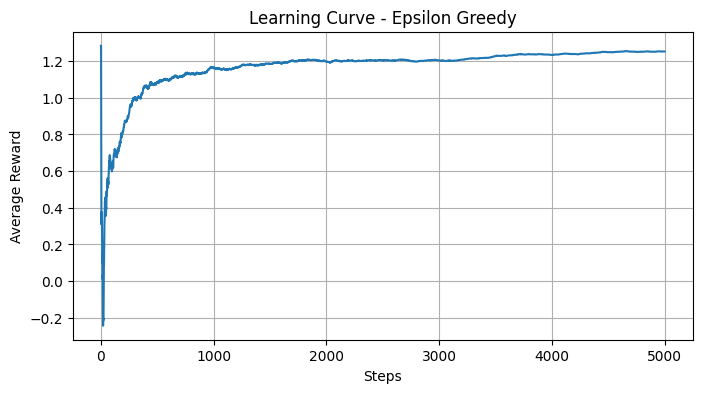

In [105]:
plt.figure(figsize=(8,4))

plt.plot(
    average_rewards
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Average Reward"
)

plt.title(
    "Learning Curve - Epsilon Greedy"
)

plt.grid()
plt.show()

The first graph illustrates the expected behavior of an ε-greedy agent.

At the start of training:
- The agent has no prior knowledge of the environment.
- Q(a) values ​​for all actions are zero.
- Selections are largely random.
- Consequently, the reward fluctuates significantly.

During the first few hundred steps:
- The agent begins estimating the values ​​of the arms.
- The average reward rises rapidly.
- It approaches a stable value around steps 500 to 1000.

Subsequently:
- The reward levels off; this indicates that the agent has successfully identified the optimal arm and is selecting it more frequently.

Important note:
The graph does not become perfectly flat, as the agent is still required to explore 10% of the time, during which it may select a suboptimal action.

#### Metric 2 — Regret

One of the most important Bandit metrics:

If we had known the best arm from the start:

$Optimal Reward$

But we:

$Obtained Reward$

obtained.

Thus:

$Regret = Optimal - Obtained$


In [106]:
regret = np.cumsum(
    best_reward - np.array(rewards)
)

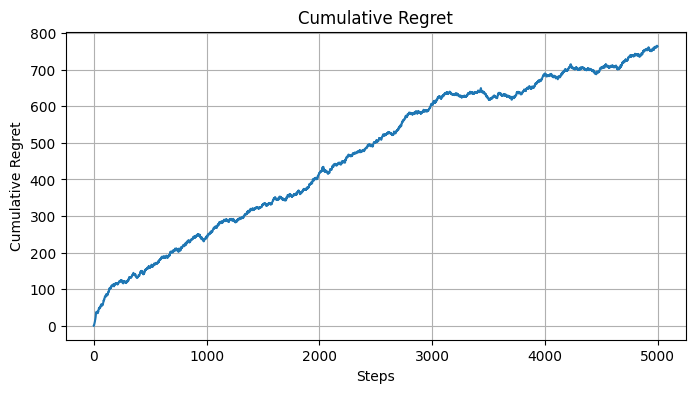

In [107]:
plt.figure(figsize=(8,4))

plt.plot(
    regret
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Cumulative Regret"
)

plt.title(
    "Cumulative Regret"
)

plt.grid()
plt.show()

#### Cumulative Regret

Sum of all regrets:

$R_t=\sum r_i$

Thus, it always increases.

At the beginning of training:
- The agent does not yet know the best arm.
- There are many incorrect choices.
- Regret increases rapidly.

After learning:
- The agent selects good actions more frequently.
- The rate of regret accumulation slows down.
However, since ε is constant, exploration continues throughout the entire training process.

Therefore:
- Regret accumulation never completely stops.
- It continues to rise at a roughly constant slope.
- This behavior is typical for standard ε-greedy.

<h3> Step 3.3: Visulization

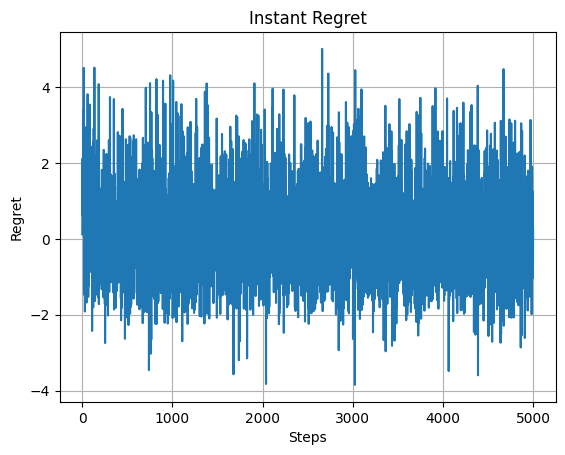

In [108]:
instant_regret = (
    best_reward -
    np.array(rewards)
)

plt.plot(
    instant_regret
)

plt.title(
    "Instant Regret"
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Regret"
)

plt.grid()
plt.show()

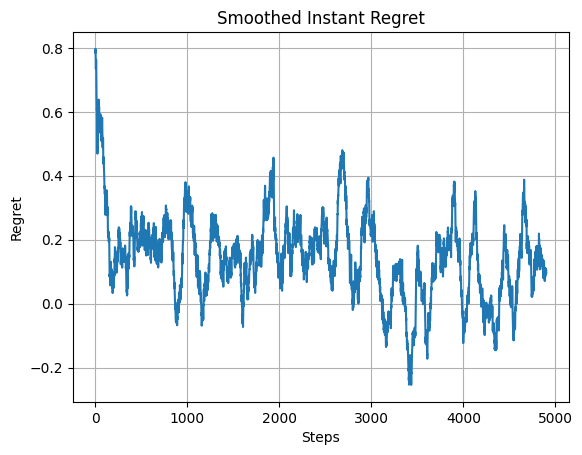

In [ ]:
window = 100

smooth_regret = np.convolve(
    instant_regret,
    np.ones(window)/window,
    mode="valid"
)

plt.plot(
    smooth_regret
)

plt.title(
    "Smoothed Instant Regret"
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Regret"
)

plt.grid()
plt.show()

What we just defined:

$Instant\ Regret_t = \mu^* - R_t$

where:
- $\mu^*$ = the true mean of the best arm
- $R_t$ = the actual reward obtained at that moment
However, the actual reward is stochastic:

$R_t \sim N(\mu_a,1)$

This means that even when the agent selects the best arm, the reward still fluctuates.

For the bandit problem, we typically do not measure regret in this way.

In the multi-armed bandit literature, "expected regret" is commonly used:

$r_t = \mu^* - \mu_{A_t}$

rather than:

$\mu^* - R_t$

That is, instead of the stochastic reward, we use the true mean of the selected arm.

In [115]:
chosen_means = np.array([
    bandit.means[a]
    for a in actions
])

regret = (
    best_reward -
    chosen_means
)

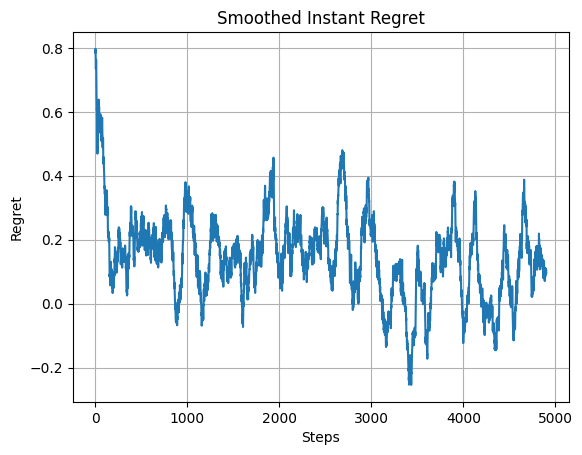

In [116]:
window = 100

smooth = np.convolve(
    regret,
    np.ones(window)/window,
    mode="valid"
)

plt.plot(
    smooth_regret
)

plt.title(
    "Smoothed Instant Regret"
)

plt.xlabel(
    "Steps"
)

plt.ylabel(
    "Regret"
)

plt.grid()
plt.show()

### Regret Analysis

Instant regret based on observed rewards can be highly noisy because rewards are sampled from stochastic distributions.

To better evaluate the learning process, expected regret was analyzed using the true mean reward of each selected arm.

At the beginning of training, regret is high because the agent explores different actions without knowing their actual values.

As training progresses, the agent identifies better actions and selects the optimal arm more frequently, causing the regret growth rate to decrease.

The remaining fluctuations are caused by the exploration factor (`epsilon`), which allows occasional random actions even after learning.

This demonstrates the exploration-exploitation trade-off in epsilon-greedy algorithms.

In [117]:
print("True values:")
print(bandit.means)

print("\nAgent estimation:")
print(agent.values)

True values:
[ 1.10065594  0.32027241  1.12943062 -0.20041382 -1.49793904 -0.14412657
  0.280359   -1.67677136  1.40504003 -0.18612675]

Agent estimation:
[ 1.24427244  0.28190855  0.99841103 -0.26368986 -1.5070738  -0.15456299
  0.23780325 -1.57471647  1.41750411 -0.24364235]


In [120]:
print("Best true arm:",
      np.argmax(bandit.means))

print("Agent best arm:",
      np.argmax(agent.values))

Best true arm: 8
Agent best arm: 8


A few key points:

1. The estimates are very close to one another.
2. Preservation of the arm ranking:
The agent has not merely identified the best arm; it has learned almost the entire structure of the environment.
3. Reasons for the discrepancies:
The agent's values ​​are not exactly equal because:
    - The sample size is limited.
    - Rewards are stochastic.
    - Exploration is still active (epsilon = 0.1).

#### Value Estimation Analysis

After training the epsilon-greedy agent, the estimated action values were compared with the true reward distributions of the environment.

The agent successfully learned the value of each arm and identified the optimal action.

The best arm according to the environment was:

Arm 8

The agent estimation also selected:


Arm 8

The estimated values were close to the true values, with small differences caused by stochastic rewards and limited training samples.

This confirms that the epsilon-greedy strategy can effectively learn the optimal action through repeated interaction and reward feedback.